# ABCMB Fluids

In this notebook, we demonstrate how to efficiently implement a new particle species to the cosmological model, using the `Fluid` module in ABCMB.

# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

from classy import Class
from abcmb.main import Model
from abcmb.species import Fluid, StandardFluid, BackgroundFluid
import abcmb.constants as cnst
from abcmb import species, spectrum

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import equinox as eqx

ERROR:2026-02-11 14:49:01,512:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda13.initialize()
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax_plugins/xla_cuda13/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax_plugins/xla_cuda13/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.
ERROR:2026-02-11 14:49:02,019:jax._src.xla_bridge:477: Jax plugin conf

# A $\Lambda {\rm CDM}$ Run

We first perform a standard cosmology run to compare our subsequent results to.

In [7]:
LCDM = Model()
output_LCDM, aux_LCDM = LCDM.run_cosmology({})


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



In [8]:
l = aux_LCDM[0]
tt = output_LCDM[0] * l * (l+1) / 2 / jnp.pi
te = output_LCDM[1] * l * (l+1) / 2 / jnp.pi
ee = output_LCDM[2] * l * (l+1) / 2 / jnp.pi

k = aux_LCDM[1]
Pk = output_LCDM[3]

# Adding new fluids: $\Lambda {\rm CDM}+m_\nu$

Once a new cosmological fluid is defined, it's trivial to add it to ABCMB.  We'll describe how to define a new fluid in the next few sections.  For now, we will work with massive neutrinos, which are already implemented in ABCMB with a class `MassiveNeutrino`; the class itself is defined in `abcmb.species`, and the relevant physics is outlined in the companion paper.  Let's see how to add it to ABCMB.

We must first create an `abcmb.Model` which contains the massive neutrino fluid, along with the five default $\Lambda {\rm CDM}$ fluids. To do so, we will define a new tuple name `user_species`, which is passed in upon model creation:

In [7]:
user_species = (
    species.MassiveNeutrino, # Object user_species must be a tuple, so don't forget the comma!!!
)
LCDM_mnu = Model(user_species=user_species)
print("LCDM+neutrino mass:")
print(LCDM_mnu.species_dict)

LCDM+neutrino mass:
{'DarkEnergy': 0, 'ColdDarkMatter': 1, 'Baryon': 2, 'Photon': 3, 'MasslessNeutrino': 4, 'MassiveNeutrino': 5}


As demonstrated in the model's `species_dict`, a massive neutrino fluid has been tacked onto the model's species management. Its relevant functions will be called throughout the remaining computation.

⚠️ WARNING!

The object we included in `user_species` is the class `species.MassiveNeutrino`, NOT an instance `species.MassiveNeutrino()`. This subtle yet important difference is by design.  As we will discuss in the next section, all ABCMB fluids have an index, which may depend on the other fluids present in the cosmology.  Instantiating the object before passing it into `user_species` would incorrectly set the index (or worse, require the user to set it correctly themselves).  Therefore `user_species` expects the class itself and not an instance of the class.  ABCMB will create the instance of the Fluid for you, while keeping track of the correct indices.

Massive neutrino suppress the matter power spectrum on small scales. Let's see this in action by computing P(k) in both models:

In [8]:
params_LCDM_mnu = {
    "N_nu_massless" : 2,
    "T_nu_massless" : 0.71636856,
    "N_nu_massive"  : 1,       # Number of literal species of massive neutrinos
    "T_nu_massive"  : 0.71611, # Massive neutrino effective temperature.
    "m_nu_massive"  : 0.06,     # Neutrino mass, in eV
}
output_mnu, aux_mnu = LCDM_mnu.run_cosmology(params_LCDM_mnu)
Pk_mnu = output_mnu[3]
tt_mnu = output_mnu[0] * l * (l+1) / 2 / jnp.pi

# note ABCMB recompiles as compared to our LCDM example above;
# this is expected, since we've changed the number of species
# in our model


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



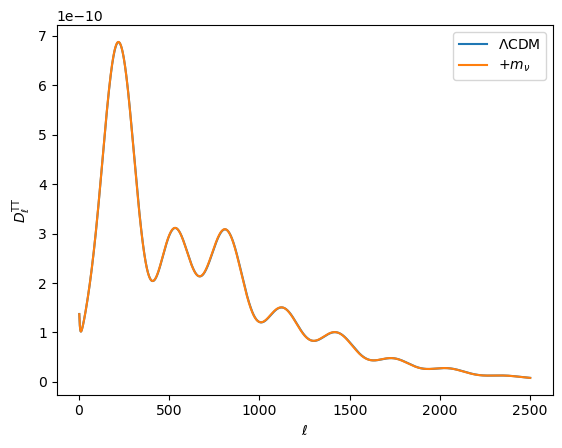

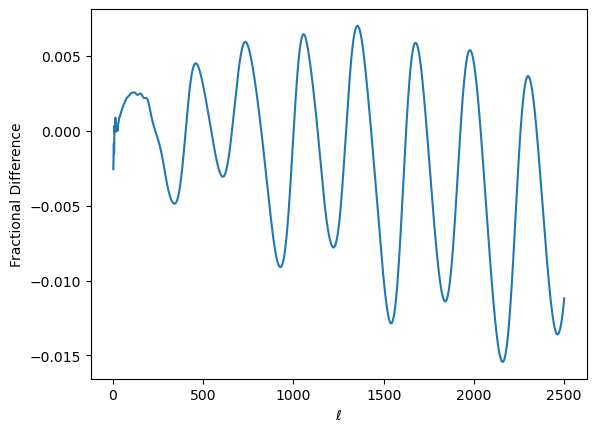

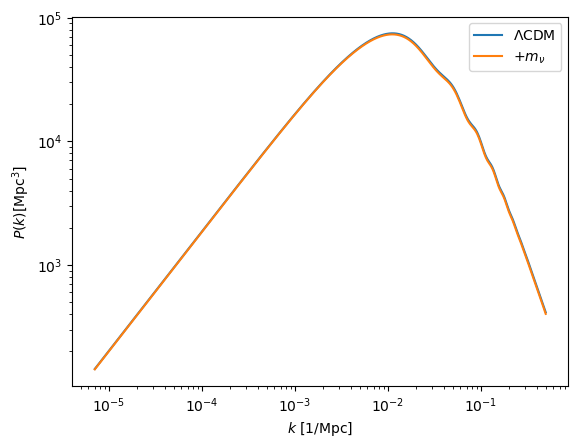

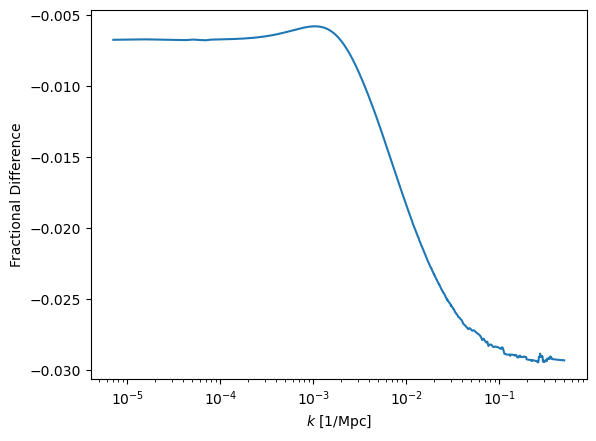

In [9]:
plt.plot(l, tt, label=r"$\Lambda {\rm CDM}$")
plt.plot(l, tt_mnu, label=r"$+m_\nu$")
plt.legend()
plt.ylabel(r"$D_\ell^{\rm TT}$")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, tt_mnu/tt - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$\ell$")
plt.show()

plt.loglog(k, Pk, label=r"$\Lambda {\rm CDM}$")
plt.loglog(k, Pk_mnu, label=r"$+m_\nu$")
plt.legend()
plt.ylabel(r"$P(k) [{\rm Mpc}^3]$")
plt.xlabel(r"$k\ [1/{\rm Mpc}]$")
plt.show()

plt.plot(k, Pk_mnu/Pk - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$k\ [1/{\rm Mpc}]$")
plt.xscale("log")
plt.show()

# Defining new fluids: The Fluid Module

What if you want to add a new fluid, like warm dark matter, inderacting dark radiation, or dynamical dark energy, to ABCMB?  These fluids don't ship with ABCMB, but they are trivial to define and add to it, without you ever needing to open a source file. We accomplish this by reuqiring all species are constructed based off of the ABCMB `Fluid` module.

The `Fluid` modules are the building blocks of a cosmological model in ABCMB. Each module contains labels, characteristics, as well as instructions on how to compute various functions that are unique to that fluid. 

## The Module

Each fluid should inherit from the base class `Fluid` in ABCMB.  This is stored in `species.py`, though we've copied it here for quick reference.  This is an `equinox` module (see https://github.com/patrick-kidger/equinox ), which makes object-oriented programming in JAX feel more like object-oriented programming in pure python.

In [5]:
class Fluid(eqx.Module):
    """
    Base class for fluid species.

    Defines fluid properties.

    Fields:
    -------
    delta_idx : int
        Default = 0
        Position of the first perturbation equation in the Diffrax vector. For most fluids this is the density 
        perturbation mode "delta".
    num_ell_modes : int 
        Default = 0
        Number of equations that need to be simultaneously evolved in the perturbations module. 
    name : str
        Default = ""
        Name of the fluid, used to find fluid and refer to it later in the computation using species_dict["name"].
    is_matter : bool
        Default = False
        Whether the fluid is non-relativistic today and contributes towards the total matter power spectrum. 

    Methods:
    --------
    Background Quantities:
        rho : Compute energy density (units: eV cm^{-3})
        P   : Compute pressure (units: eV cm^{-3})
        w   : Compute equation of state parameter (units: dimensionless)

    Perturbation Quantities:
        y_ini   : Adiabatic initial conditions, in synchronous gauge
        y_prime : Perturbation derivatives, in synchronous gauge
        rho_delta        : Perturbed density function δρ (units: eV cm^{-3})
        rho_plus_P_theta : Velocity perturbation  (units: eV cm^{-3})
        rho_plus_P_sigma : Compute standard shear perturbation (units: eV cm^{-3})
    """

    delta_idx     : int = eqx.field(default=0)
    num_ell_modes : int = eqx.field(default=0, static=True)
    name          : str = eqx.field(default="")
    is_matter     : bool = eqx.field(default=False) # Does the fluid contribute towards matter overdensity today.

    def __init__(self, delta_idx, specs):
        self.delta_idx = delta_idx

    def rho(self, lna, args):
        raise NotImplementedError("Fluid species must implement an energy density function.")

    def P(self, lna, args):
        raise NotImplementedError("Fluid species must implement a pressure function.")

    def w(self, lna, args):
        return self.P(lna, args)/self.rho(lna, args)

    def y_ini(self, k, tau_ini, args):
        raise NotImplementedError("Fluid species must implement the initial conditions of their perturbation modes.")

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        raise NotImplementedError("Fluid species must implement a perturbation derivative function.")

    def rho_delta(self, lna, y, args):
        raise NotImplementedError("Fluid species must implement a perturbation derivative function.")

    def rho_plus_P_theta(self, lna, y, args):
        raise NotImplementedError("Fluid species must implement a perturbation derivative function.")

    def rho_plus_P_sigma(self, lna, y, args):
        raise NotImplementedError("Fluid species must implement a perturbation derivative function.")

## The Equinox Fields

Let's start by looking at the fields--these are the expressions that appear above `__init__`. If you're new to object-oriented programming or new to `equinox`, these fields act as labels for a specific instance of the class `Fluid`. Think of drivers licenses; every license has a spot for a name, DOB, address, etc. - these are the fields. Your license and mine both have these fields, but the specific names and the specific addresses on them are unique!

The fields include attributes that do not change with cosmological parameters.  Changing a field requires instantiating the object again.  ABCMB fluids require the following fields:

- `delta_idx` is an integer that tracks the position of the first perturbation equation for the fluid. For most fluids, this equation is the density perturbation, usually denoted $\delta$. When a fluid is added to an ABCMB model, the appropriate value is automatically updated with respect to the other fluids present. Therefore you will never have to manually assign a value for `delta_idx`; nonetheless the field must be defined so a value can be assigned later. If you're simply testing the fluid on its own you may leave the default value of `delta_idx=0`.

- `num_ell_modes` is an integer that counts the total number of perturbation equations the fluid has. Setting this at compile time is important to inform ABCMB how many total equations it should expect when computing perturbations with this fluid present. For example, Cold Dark Matter (CDM) in the synchronous gauge only has a density perturbation, so it has `num_ell_modes=1`. In contrast, photons need a full Boltzmann hierarchy for both the temperature and polarization modes, so its `num_ell_modes` will be the size of the two hierarchies combined. 

- `name` is a string, whatever you'd like to call your fluid.  You can name the fluid whatever you want, but 1) for programming clarity we recommend that it makes sense, and 2) if you add a new dark matter fluid, there are some advanced cases in which you may want to ensure the string `'darkmatter'` (any capitalization) appears somewhere in its name.  We will show how the name is useful later when we work with coupled fluid species.

- `is_matter` is a boolean flag. It is `False` by default and you should only set it to `True` if your fluid is non-relativistic today. ABCMB will read this flag and know to include the fluid in the matter power spectrum. For example, the presently implemented species `MassiveNeutrino` contains `is_matter=True`, so a run with massive neutrinos automatically includes them in $P(k)$.


## The Methods

If the flags describe what the fluids _are_, then the methods describe what they _do_. All `Fluid`s must have:

- `__init__` tells a class how to set its fields upon initialization. The `Fluid` objects expect two parameters in the init: `delta_idx`, which again is automatically determined and passed by ABCMB, and a dictionary called `specs`. `specs` contains precision-related parameters that do not vary with cosmological parameters. For example, the `__init__` method in the `Photon` fluid in ABCMB uses `specs["l_max_g"]` to set the Boltzmann hierarchy cutoff, and therefore its `num_ell_modes`. You can add any precision parameter related to your fluid to specs as well before starting a run.
- `rho` computes the background energy density as a function of $\ln{a}$. ⚠️WARNING: all fluid densities in ABCMB must have a standard unit of ${\rm eV}/{\rm cm}^3$!
- `P` computes the pressure, in the same units as `rho`.
- `w` is the density of state parameter as a function of $\ln{a}$; note this is automatically defined in terms of the model's `rho` and `P`.
- `y_ini` computes and returns the superhorizon initial conditions for the fluid's perturbations, given the wavenumber $k$, and initial conformal time $\tau$. It should return a `jnp.array` that is the same size as the fluid's `num_ell_modes`.
- `y_prime` computes the derivatives for the fluid's perturbation equations. It should return a `jnp.array` that is size `num_ell_modes`, and the position of each derivative within the array should match the corresponding position in `y_ini`. 
- `rho_delta` returns the density perturbation $\delta \rho$ that contributes towards the perturbed metric.
- `rho_plus_P_theta` returns the velocity perturbation that contributes towards the perturbed metric.
- `rho_plus_P_sigma` returns the anisotropic shear perturbation that contributes towards the perturbed metric and its derivative, needed for the CMB power spectrum.

The perturbations are organized into a vector `y`, which contains the modes of the Boltzmann hierarchy.  `y` contains the current value of the perturbations (initialized to `y_ini`), while the corresponding entries in `y_prime` contain the derivatives of those modes.  Internally in ABCMB, perturbations for _all_ species are included in one vector `y`, with `delta_idx` and `num_ell_modes` used to locate the perturbations and their derivatives belonging to a given fluid.

That concludes the ingredients that form an ABCMB fluid. To use ABCMB to study your new physics scenario, collect these information about your fluid, make a module and pass it into an ABCMB model!  In the next sections we will show you how to define some new fluids and add them to ABCMB.

# Example: $w_0w_a {\rm CDM}$ (Dynamical Dark Energy)

Let's see how to define a new fluid that doesn't ship with ABCMB, and add it to our cosmological model.

Dynamical dark energy (DDE) has received much attention in light of recent DESI data. In this model, the constant dark energy equation of state $w=-1$ is modified with the time dependence $w(a) = w_0 + (1-a)w_a$. I ts energy density is therefore no longer constant, but redshifts according to $\rho \propto a^{-3(1+w(a))}$.

In the minimal example below, the now-dynamical dark energy only modifieds the background energy density without introducing any perturbations (e.g., we will leave scenarios where DE interacts with dark matter as an exercise for the reader).

We could inherit from `Fluid`; though ABCMB has a few other tools to make defining classes like this a little faster.  These are the `StandardFluid` and `BackgroundFluid` objects, which inherit from `Fluid` but define some standard quantities.  They're included in `species.py`, but we've copied `BackgroundFluid` below for quick reference:

In [3]:
class BackgroundFluid(Fluid):
    
    num_ell_modes = 0

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)

    def y_ini(self, k, tau_ini, args):
        """
        Trivial initial condition vector for background.
        """
        return jnp.array([])

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        """
        Trivial derivative vector for background. 
        """
        return jnp.array([])

    def rho_delta(self, lna, y, args):
        return 0.

    def rho_plus_P_theta(self, lna, y, args):
        return 0.

    def rho_plus_P_sigma(self, lna, y, args):
        return 0.

See how `num_ell_modes` is already defined, the perturbations equations have been set to empty arrays, and the density, velocity, and shear perturbations have been set to zero?  This is because we anticipated users might like to add something dark-energy-like to ABCMB, and all dark-energy-like fluids (i.e. fluids that do not have perturbations and instead only modify the background) have these properties.  The user only needs to specify `rho` and `P` when inheriting from this class instead of `Fluid`:

In [4]:
class DynamicalDarkEnergy(species.BackgroundFluid): # inherits from BackgroundFluid, not Fluid!

    num_ell_modes = 0 # This fluid has no perturbations; this is set for illustration here but is already set to 0 in BackgroundFluid
    name = "DynamicalDarkEnergy" # Give it a name
    
    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs) # Standard super init procedure, needed for all fluids

    def rho(self, lna, params):
        """
        Energy density at log scale factor lna,
        in units of eV/cm^3.
        """
        rho_i = params["omega_Lambda"] * (3.*cnst.H0_over_h**2/8./jnp.pi/cnst.G)
        a = jnp.exp(lna)

        # Below is obtained by solving continuity equation \dot{\rho} = -3H\rho*(1+w)
        return rho_i \
        * a**(-3.*(1.+params["w0DE"]+params["waDE"])) \
        * jnp.exp(3*params["waDE"]*(a-1))

    def P(self, lna, params):
        """
        Pressure at log scale factor lna.
        """
        a = jnp.exp(lna)
        w = params["w0DE"] + (1-a)*params["waDE"]
        return w*self.rho(lna, params)

Next we want to add this new fluid to ABCMB for computation.  

⚠️ WARNING!

We need to be careful not to double count the dark energy. By default, ABCMB includes all $\Lambda$CDM species, which already includes $\Lambda$ dark energy. Therefore we must:
1) tell ABCMB not to use any default species, and
2) specify all fluids ourselves:

In [5]:
specs = {
    "use_LCDM_species" : False # First, ask ABCMB not to use default species
}

# Since we're not using the default species set, we need to add all the other fluids too.
user_species = {
    species.Baryon,
    species.Photon,
    species.ColdDarkMatter,
    species.MasslessNeutrino,
    DynamicalDarkEnergy
}

w0wa = Model(specs, user_species=user_species)
print("w0wa:")
print(w0wa.species_dict)

w0wa:
{'DynamicalDarkEnergy': 0, 'ColdDarkMatter': 1, 'Baryon': 2, 'Photon': 3, 'MasslessNeutrino': 4}


As we can see we still have the five fluids in this model, only dark energy has been replaced by our `DynamicalDarkEnergy`. We are ready to run as long as we remember to pass in our BSM parameters, `w0DE` and `waDE`. Let's see how it compares to $\Lambda {\rm CDM}$.

In [6]:
params = {
    "w0DE" : -0.8,
    "waDE" : -0.6,
}

output_w0wa, aux_w0wa = w0wa.run_cosmology(params)

# the model recompiles here as well--because we've added new fluids
# to it again


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



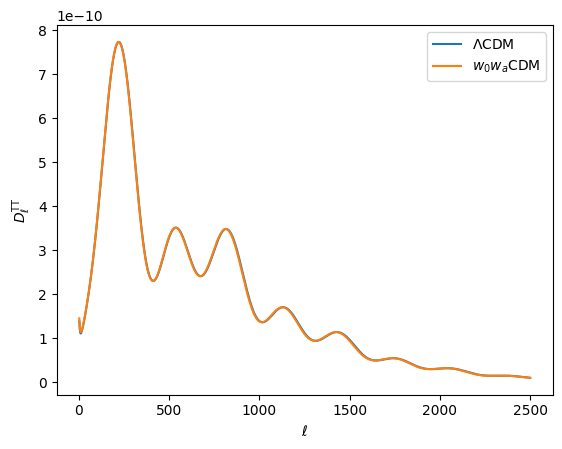

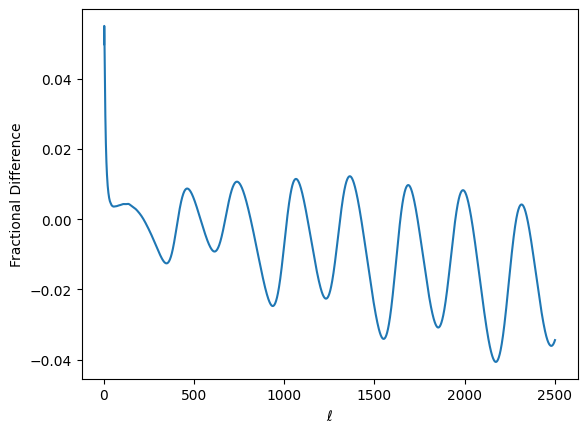

In [9]:
# Compare
tt_w0wa = output_w0wa[0] * l * (l+1) / 2 / jnp.pi

plt.plot(l, tt, label=r"$\Lambda {\rm CDM}$")
plt.plot(l, tt_w0wa, label=r"$w_0 w_a {\rm CDM}$")
plt.legend()
plt.ylabel(r"$D_\ell^{\rm TT}$")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, tt_w0wa/tt - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$\ell$")
plt.show()

# Example: SIDR

The next example includes both background modifications and extra perturbations. We consider a strongly self interacting dark radiation scenario. The dark sector consists of an isolated, massless (or very light) particle whose self interaction is always stronger than Hubble. In this model, the only relevant perturbations are the density and velocity perturbations, and no higher moments are needed. These two modes obey the time evolution equations

$
\begin{align}
\delta_{\rm dr}' &= -\frac{4 \theta_{\rm dr}}{3 \mathcal{H}} - \frac{2}{3}h' \\
\theta_{\rm dr}' &= \frac{k^2 \delta_{\rm dr}}{4 \mathcal{H}}\, ,
\end{align}
$

where $'$ denotes derivative w.r.t. $\ln{a}$, which is required in ABCMB.

In this case, it will be faster to inherit from ABCMB's `StandardFluid` class, rather than all the way from `Fluid`.  `StandardFluid` is defined in `species.py` and is pasted below for reference:

In [ ]:
class StandardFluid(Fluid):
    """
    Standard implementation of perturbation methods for fluid species.

    Provides default computations for perturbation-related methods
    used in this code.

    Methods:
    --------
    rho_delta : Compute standard density perturbation (units: eV cm^{-3})
    rho_plus_P_theta : Compute standard velocity perturbation (units: eV cm^{-3})
    rho_plus_P_sigma : Compute standard shear perturbation (units: eV cm^{-3})
    """

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)

    # Called by diffrax, child classes should never override. Okay to implement here.
    def rho_delta(self, lna, y, args):
        """
        Compute density perturbation.

        Parameters:
        -----------
        lna : float
            Logarithm of scale factor
        y : array
            Perturbation mode values
        args : dict
            Cosmological parameters (params)

        Returns:
        --------
        float
            Density perturbation (units: eV cm^{-3})
        """
        params = args
        return self.rho(lna, params) * y[self.delta_idx]

    def rho_plus_P_theta(self, lna, y, args):
        """
        Compute velocity perturbation.

        Parameters:
        -----------
        lna : float
            Logarithm of scale factor
        y : array
            Perturbation mode values
        args : dict
            Cosmological parameters (params)

        Returns:
        --------
        float
            Velocity perturbation (units: eV cm^{-3})
        """
        params = args
        return jnp.where(
            self.num_ell_modes > 1,
            (self.rho(lna, params)+self.P(lna, params)) * y[self.delta_idx+1],
            0.
        )

    def rho_plus_P_sigma(self, lna, y, args):
        """
        Compute shear perturbation.

        Parameters:
        -----------
        lna : float
            Logarithm of scale factor
        y : array
            Perturbation mode values
        args : dict
            Cosmological parameters (params)

        Returns:
        --------
        float
            Shear perturbation (units: eV cm^{-3})
        """
        params = args
        return jnp.where(
            self.num_ell_modes > 2,
            (self.rho(lna, params)+self.P(lna, params)) * y[self.delta_idx+2],
            0.
        )

We've already done the work of defining the three metric perturbation functions for a generic perturbed fluid, where the three metric perturbation functions $\rho \delta$, $(\rho+P)\theta$ and $(\rho+P)\sigma$ are already set.  **We recommend always inheriting from `StandardFluid`, `BackgroundFluid`, or classes that inherited from these two modules, unless the perturbations are not of the form $\delta$, $\theta$, $\sigma$, etc** (as is the case for e.g. massive neutrinos), so that your new fluids always respect the underlying index structure ABCMB is expecting.

In our SIDR example, we therefore only need to implement two background functions $\rho$ and $P$, as well as two perturbation functions `y_ini` and `y_prime`:

In [5]:
class SIDR(StandardFluid):
    
    # Number of modes in the Boltzmann Hierarchy
    num_ell_modes = 2 # Non free-streaming species only require density and velocity perturbations

    name = "SIDR"

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)
    
    def rho(self, lna, params):
        """
        Energy density at log scale factor lna.
        Should be in units of eV/cm^3.

        Here the energy density is parameterized in terms of the number of extra SM neutrino species:
        
        rho1nu = 7/8 x (4/11)^(4/3) x rhoCMB

        where rhoCMB = pi^2/15 TCMB0^4 / a^4,

        and rho_idr = N_idr x rho1nu
        """
        a = jnp.exp(lna)

        # Note: params['TCMB0'] is in eV, so we need three factors of 1/(hbar c) to convert to eV/cm^3
        rho1nu = 7./8. * (4./11.)**(4./3.) * jnp.pi**2 / 15. * params['TCMB0']**4 / a**4 / (cnst.hbar*cnst.c)**3
        return params["N_idr"] * rho1nu

    def P(self, lna, params):
        """
        Pressure at log scale factor lna.
        For fully relativistic species this is simply rho/3.
        """
        return self.rho(lna, params)/3.

    def y_ini(self, k, tau_ini, args):
        """
        Adiabatic superhorizon initial conditions for SIDR.
        For all relativistic species they are matched to neutrinos.
        """
        params = args
        R_nu = params['R_nu']

        delta = - (k*tau_ini)**2/3. * (1.-params["om"]*tau_ini/5.)
        theta = - k*(k*tau_ini)**3/36./(4.*R_nu+15.) \
                * (4.*R_nu+11.+12.-3.*(8.*R_nu**2+50.*R_nu+275.)/20./(2.*R_nu+15.)*tau_ini*params["om"])
        return jnp.array([delta, theta])

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        """
        Derivatives of the SIDR perturbations w.r.t. lna.
        """
        BG, params, _, _ = args
        aH = BG.aH(lna, params)

        # First find the delta and theta that belong to SIDR
        delta = y[self.delta_idx]
        theta = y[self.delta_idx+1]
        
        delta_prime = -4./3./aH*theta - 2./3.*metric_h_prime
        theta_prime = k**2/aH*delta/4.

        return jnp.array([delta_prime, theta_prime])

Here `y_ini` returns the two values for the initial $\delta$ and $\theta$. The expressions are matched to CLASS sychronous gauge, and in particular uses the `om` parameter defined as $\omega \equiv \frac{\Omega_m}{\sqrt{\Omega_r}}H_0$, as well as $R_\nu \equiv \rho_\nu / \rho_r$.

The arguments of `y_prime` include the wavenumber, time, the two metric perturbations, the full perturbation equations vector `y`, as well as a tuple `args = (BG, params, species_list, species_dict)`. `BG` and `params` provide the background quantities and cosmological parameters respectively, while the `species_list` and `species_dict` provide pointers to other fluids that are not needed for now. These will become relevant when we next look at a coupled species.  

We can add this new fluid to ABCMB as above; since we're not overwriting any $\Lambda$CDM species we don't need to worry about adding those species manually:

In [7]:
# Here since SIDR is an extra fluid and is not meant to replace any LCDM fluids, we can leave the default species on.
user_species = (
    SIDR,
)

specs = {
    "max_steps_PE" : 4096,
}

SIDRmodel = Model(specs, user_species)
print("SIDR model:")
print(SIDRmodel.species_dict)

SIDR model:
{'DarkEnergy': 0, 'ColdDarkMatter': 1, 'Baryon': 2, 'Photon': 3, 'MasslessNeutrino': 4, 'SIDR': 5}


Here we used an extra `specs` parameters `max_steps_PE`. This parameter tells the adaptive step size solver what is the maximum number of steps it should expect to take, in order to solve the linear perturbations equations. This number is 2048 by default, but adding new physics scenarios such as the SIDR can make these equations more difficult. With this method we allow our solver to take more steps to solve, though this may increase runtime. 

In [10]:
params = {
    'N_idr' : jnp.array(.3), # Only extra parameter, number of equivalent SM neutrinos.
}

In [9]:
output_SIDR, aux_SIDR = SIDRmodel.run_cosmology(params)

You did not specify either N_nu_massless or Neff, and did not ask LINX to compute these quantities.
N_nu_massless will be set to 3-N_nu_massive=3.

              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



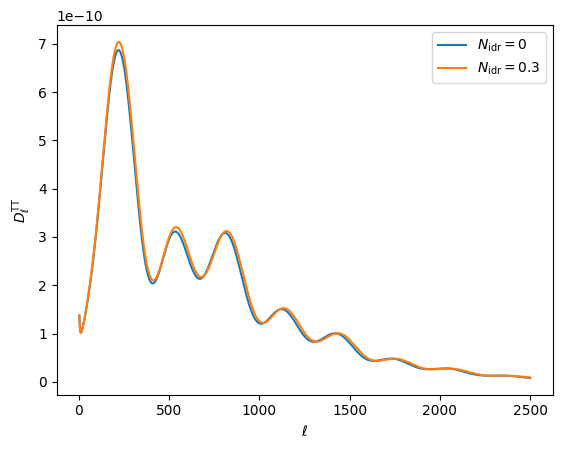

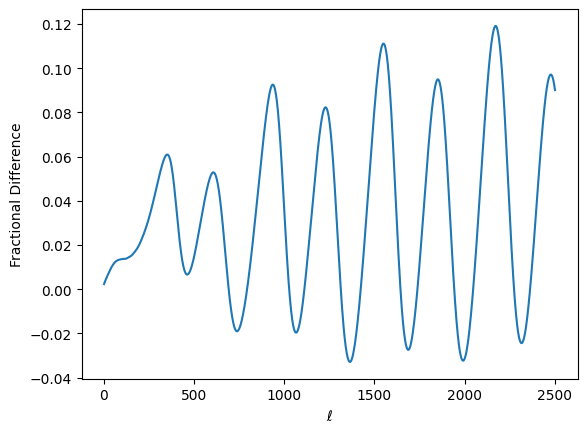

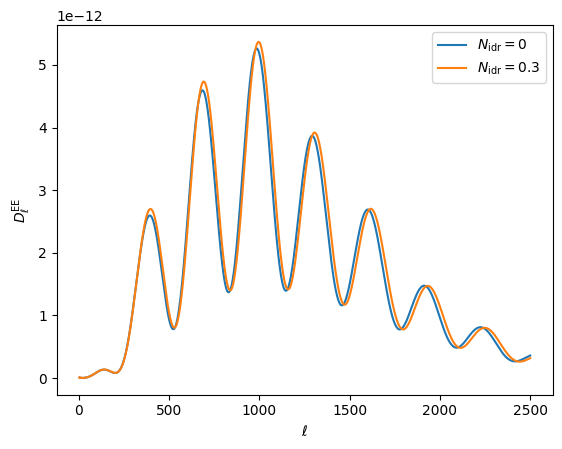

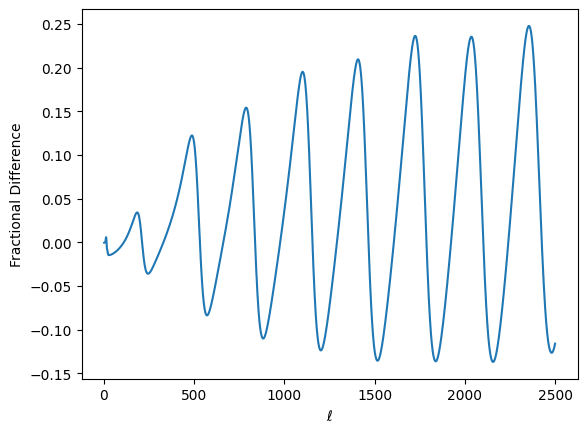

In [33]:
tt_SIDR = output_SIDR[0] * l * (l+1) / 2 / jnp.pi
ee_SIDR = output_SIDR[2] * l * (l+1) / 2 / jnp.pi

plt.plot(l, tt, label=r"$N_{\rm idr}=0$")
plt.plot(l, tt_SIDR, label=r"$N_{\rm idr}=0.3$")
plt.legend()
plt.ylabel(r"$D_\ell^{\rm TT}$")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, tt_SIDR/tt - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, ee, label=r"$N_{\rm idr}=0$")
plt.plot(l, ee_SIDR, label=r"$N_{\rm idr}=0.3$")
plt.legend()
plt.ylabel(r"$D_\ell^{\rm EE}$")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, ee_SIDR/ee - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$\ell$")
plt.show()

# Example: Non-Abelian Dark Matter

In this final example, we will see how fluids can interact in ABCMB. This is also acomplished easily with the `Fluid`/`StandardFluid` modules.

Consider a dark sector scenario where all of the dark matter mildly scatters with dark radiation. This can be realised in the Non-Abelian Dark Matter (NADM) model (see https://arxiv.org/pdf/1708.09406 ), implementated in CLASS under the NADM parameterization. Let's focus on the case where the dark radiation itself strongly interacts to maintain a fluid nature.  The velocity perturbations of the dark matter and dark radiation are

$
\begin{align}
\theta_{\rm dm}' &= -\theta_{\rm dm} + \frac{\Gamma_{0, {\rm nadm}}}{a \mathcal{H}} (\theta_{\rm dr}-\theta_{\rm dm})\\
\theta_{\rm dr}' &= \frac{k^2 \delta_{\rm dr}}{4 \mathcal{H}} + R\frac{\Gamma_{0, {\rm nadm}}}{a \mathcal{H}} (\theta_{\rm dm}-\theta_{\rm dr})\\
R &\equiv \frac{3 \rho_{\rm dm}}{4 \rho_{\rm dr}}\, ,
\end{align}
$

where $R$ enforces energy-momentum conservation, and $\Gamma_{0, {\rm nadm}}$ is the dark matter-dark radiation collision rate today, in units of $1/{\rm Mpc}$.


Once again, we can use object inheritance to save ourselves a good bit of trouble. This is by recognizing that the IDM class is not entirely different from CDM; they differ only at the perturbations level while having the same background energy density. So we can define a new class

In [44]:
class IDM(species.ColdDarkMatter):

    num_ell_modes = 2 # Interacting DM will have velocity perturbation, unlike CDM
    name = "InteractingDarkMatter"

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)

    def y_ini(self, k, tau_ini, args):
        """
        Adiabatic initial conditions.
        For non-relativistic species we match to CDM and baryons for density, and baryons for velocity
        """
        params = args
        delta = -(k*tau_ini)**2/4. * (1.-params["om"]*tau_ini/5.)
        theta = - k**4 * tau_ini**3/36. * (1.-3.*(1.+5.*params['R_b']-params['R_nu'])/20./(1.-params['R_nu'])*params["om"]*tau_ini)
        return jnp.array([delta, theta])

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        BG, params, species_list, species_dict = args
        
        # Get IDR from list
        i = species_dict["InteractingDarkRadiation"] 
        IDR = species_list[i]

        a = jnp.exp(lna)
        aH = BG.aH(lna, params)

        delta = y[self.delta_idx]
        theta = y[self.delta_idx+1]
        theta_idr = y[IDR.delta_idx+1]
        
        delta_prime = -theta/aH-metric_h_prime/2.
        theta_prime = -theta + params["Gamma_0_nadm"]/a/aH * (theta_idr - theta)
        
        return jnp.array([delta_prime, theta_prime])

where we have given the class a new name as well as updated its `num_ell_modes=2`, now having a velocity perturbation as well. We have only implemented a new initial conditions function and a new derivative functions. If we call `IDM.rho()` or `IDM.rho_delta()`, the inherited functions from the parent class `ColdDarkMatter` will execute. Meanwhile we overwrote the parent class's `y_ini()` and `y_prime()`, so if we call `IDM.y_ini()` or `IDM.y_prime()`, our new implementations will be used.

How will we get our dark matter to scatter with our dark radiation? The `IDM.y_prime` function needs quantities that belong to the `IDR` class because these species are coupled, but the `IDM` class only has access to its own functions and fields. How can it collect quantities such as $\theta_{\rm dr}$ and $\rho_{\rm dr}$?

We solved this problem above by passing in two book-keeping objects in the `args`: `species_list` and `species_dict`, which come in alongside the background and parameter objects.  `species_list` is a tuple containing all fluids present the computation. `species_dict` is a dictionary (key : str, value : int) that stores the index position of any particular fluid in that tuple, using that fluid's `name` as the key. With `species_list` and `species_dict`, we can easily pick out any particular fluid, which is done in the `IDM.y_prime()`.

We used `i = species_dict["InteractingDarkRadiation"] `, looking in `species_dict` to extract the position of IDR.  Then, we retrieve the fluid class itself in `species_list` with `IDR = species_list[i]`.  Note the `args` parameter is automatically passed in when your fluid is called by ABCMB, so you do not have to worry about what `args` is, and instead only about how your fluid will use it.

Once we have the `IDR` class at hand, we can simply extract $\theta_{\rm dr}$ by calling `theta_idr = y[IDR.delta_idx+1]`, using the `IDR` class' field that we now have access to.

To define the dark radiation, things are even simpler. We could have inherited from `BackgroundFluid`, but we can do even better by inheriting from the SIDR class we wrote in the previous section, where now only one line in the derivative needs modification!

In [45]:
class IDR(SIDR):

    name = "InteractingDarkRadiation"

    def __init__(self, delta_idx, specs):
        super().__init__(delta_idx, specs)

    def y_prime(self, k, lna, metric_h_prime, metric_eta_prime, y, args):
        """
        Derivatives of the SIDR perturbations w.r.t. lna.
        """
        BG, params, species_list, species_dict = args
        
        # Get IDM from list
        i = species_dict["InteractingDarkMatter"]
        IDM = species_list[i]

        a = jnp.exp(lna)
        aH = BG.aH(lna, params)
        R = 3. * IDM.rho(lna, params) / 4. / self.rho(lna, params)

        # First find the delta and theta that belong to SIDR
        delta = y[self.delta_idx]
        theta = y[self.delta_idx+1]
        theta_idm = y[IDM.delta_idx+1]
        
        delta_prime = -4./3./aH*theta - 2./3.*metric_h_prime
        theta_prime = k**2/aH*delta/4. + R * params["Gamma_0_nadm"]/a/aH * (theta_idm - theta)

        return jnp.array([delta_prime, theta_prime])

As in the dynamical dark energy case, we have a new fluid that is replacing an existing $\Lambda {\rm CDM}$ fluid. We must set the default species flag to false and manually add all necessary fluids.

In [49]:
lmax = 2500
specs = {
    "use_LCDM_species" : False,
    "max_steps_PE" : 4096,
}
user_species = (
    species.DarkEnergy, 
    IDM, 
    IDR, 
    species.Baryon,
    species.Photon, 
    species.MasslessNeutrino
)

NADMmodel = Model(specs, user_species)

Let's check that our model picked up the correct fluids:

In [50]:
NADMmodel.species_dict

{'DarkEnergy': 0,
 'InteractingDarkMatter': 1,
 'InteractingDarkRadiation': 2,
 'Baryon': 3,
 'Photon': 4,
 'MasslessNeutrino': 5}

In [51]:
params = {
    'N_idr' : jnp.array(0.3),
    'Gamma_0_nadm' : jnp.array(4.e-7),
}

In [52]:
output_NADM, aux_NADM = NADMmodel.run_cosmology(params)
Pk_NADM = output_NADM[3]
tt_NADM = output_NADM[0] * l * (l+1) / 2 / jnp.pi

You did not specify either N_nu_massless or Neff, and did not ask LINX to compute these quantities.
N_nu_massless will be set to 3-N_nu_massive=3.

              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



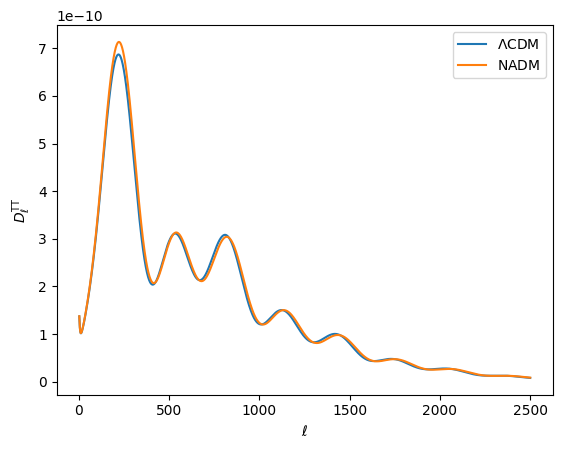

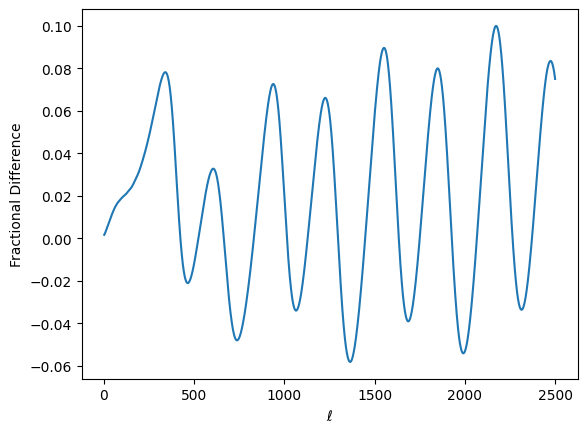

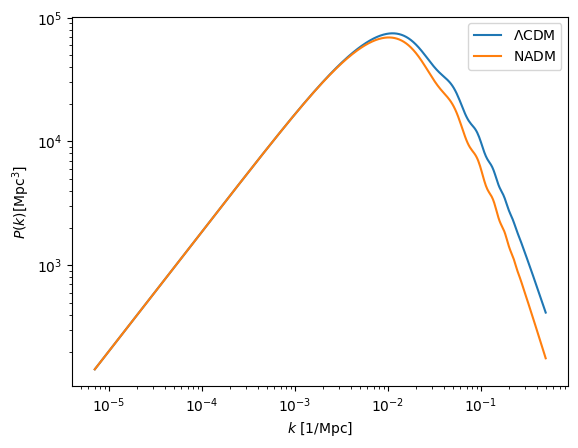

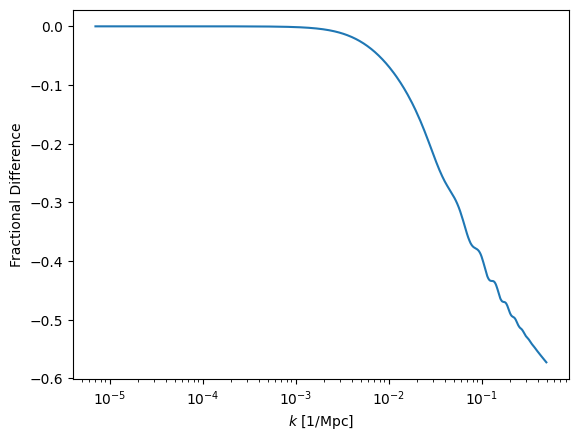

In [61]:
plt.plot(l, tt, label=r"$\Lambda {\rm CDM}$")
plt.plot(l, tt_NADM, label=r"${\rm NADM}$")
plt.legend()
plt.ylabel(r"$D_\ell^{\rm TT}$")
plt.xlabel(r"$\ell$")
plt.show()

plt.plot(l, tt_NADM/tt - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$\ell$")
plt.show()

plt.loglog(k, Pk, label=r"$\Lambda {\rm CDM}$")
plt.loglog(k, Pk_NADM, label=r"${\rm NADM}$")
plt.legend()
plt.ylabel(r"$P(k) [{\rm Mpc}^3]$")
plt.xlabel(r"$k\ [1/{\rm Mpc}]$")
plt.show()

plt.plot(k, Pk_NADM/Pk - 1.)
plt.ylabel("Fractional Difference")
plt.xlabel(r"$k\ [1/{\rm Mpc}]$")
plt.xscale("log")
plt.show()

We observe again peak shifts in the $TT$ power spectrum, mainly due to the extra dark radiation. On the matter power spectrum side, additional dark matter scattering hinders gravitational clustering, enough to suppress the power at small scales. 

# Cheat Sheet: Define your own species!

We invite you to build your new physics species here! Here's an outline for your starting choices:

First does your new physics involve cosmological perturbations? 
- If no, inherit from `BackgroundFluid`.
- If yes, are your perturbation equations ordered in $\delta, \theta, \sigma \dots$?
    - If yes, inherit from `StandardFluid` or an existing concrete fluid (like CDM, Photons, etc) and let ABCMB take care of metric perturbations for you.
    - If no, inherit directly from `Fluid`, and you must implement your own metric perturbation contributions (`rho_plus_P_theta` etc.).
 
Second, set the required fields:
- If your fluid has perturbations, set `num_ell_modes` to the appropriate number of equations.
- If your fluid is non-relativistic today and should contribute towards the matter power spectrum, set `is_matter=True`.
- Name your fluid!

Regardless of your choices above, you should now implement the `__init__` function. Copy it over from any of the existing fluids, it's only really important that you include the `super().__init__(delta_idx, specs)` line.

Implement your background functions `rho` and `P`, required for all fluids. If your fluid is at the background level only and does not need and pressure, simply implement something trivial.

For the perturbed fluids, implement your derivative functions. Make sure both `y_ini` and `y_prime` follow the input, output syntax, in particular the outputs should be `jnp.array` of size `num_ell_modes`.

If you have any unique functions or fields, they can in principle be added anywhere in this process, though note that **changing a value of a field triggers recompilation**, and so any attribute that would change over e.g. a parameter scan should go in the `params` dict, not in a new field. If instead your new fluid needs some new special auxiliary function, you can define a `MyFluid.special_function` that is called by the methods of `MyFluid` or other coupled fluids. For example, the ABCMB `Baryon` class contains a unique sound speed squared function, which is used in computing `Baryon.y_prime`.